# **Introduction — VAE Unlearning on Celebrities**

Modern generative models are trained on vast datasets scraped from the web, often including images of real individuals without explicit consent. As privacy legislation such as GDPR introduces the right to erasure, there is a growing need for machine unlearning — the ability to surgically remove a specific person's data from a trained model without retraining from scratch.
This project investigates machine unlearning applied to a Variational Autoencoder (VAE), using celebrity face images as a controlled testbed. We target the VAE specifically because, unlike a plain autoencoder, it learns a generative latent space — meaning a model that has not been properly unlearned could still produce new, synthetic images of a forgotten individual, not just reconstruct seen ones. This makes VAE unlearning a stricter and more realistic privacy guarantee.
We evaluate three unlearning strategies — Gradient Ascent, Random Noise Targeting, and Bad Teacher — measuring each method's ability to degrade reconstruction of the target celebrity (the forget set) while preserving quality for all others (the retain set).

----Imports and Dependencies----

In [2]:
import os, torch, pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from diffusers import AutoencoderKL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load celebrity dataset
import kagglehub
path = kagglehub.dataset_download("vishesh1412/celebrity-face-image-dataset")
dataset_path = os.path.join(path, "Celebrity Faces Dataset")


# appends image files to records list
records = []
for celebrity in sorted(os.listdir(dataset_path)):
    celeb_dir = os.path.join(dataset_path, celebrity)
    if not os.path.isdir(celeb_dir):
        continue
    for img_file in os.listdir(celeb_dir):
        if img_file.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"identity": celebrity, "filepath": os.path.join(celeb_dir, img_file)})

#sort based on identity label
import pandas as pd
df = pd.DataFrame(records)
identity_names = sorted(df["identity"].unique())
print(f"Total images: {len(df)}")
print(f"Celebrities: {identity_names}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


100%|██████████| 52.9M/52.9M [00:00<00:00, 173MB/s]

Extracting files...


Total images: 1800
Celebrities: ['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']


# Installing the VAE

In [3]:
# INSTALLING A PRETRAINED VAE

sd_vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
sd_vae.eval()
torch.save(sd_vae.state_dict(), 'sd_vae_orig.pt')
original_weights = {k: v.clone() for k, v in sd_vae.state_dict().items()}
sd_vae.requires_grad_(False)   # hard-freeze the reference model
print("Original weights saved and frozen.")

transform = transforms.Compose([
    transforms.Resize((256, 256)),   # SD VAE works better at 256
    transforms.ToTensor(),
])

def encode(imgs):
    imgs_scaled = imgs * 2 - 1
    with torch.no_grad():
        latent = sd_vae.encode(imgs_scaled).latent_dist.mean
    return latent

def decode(latent):
    with torch.no_grad():
        recon = sd_vae.decode(latent).sample
    return ((recon + 1) / 2).clamp(0, 1)

print("SD VAE ready")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Original weights saved and frozen.
SD VAE ready


# Creating the Celebrity Dataset Wrapper

In [4]:
from torch.utils.data import Dataset


# defines Celebrity image class wrapper
class CelebDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.df.loc[idx, "identity"]

# Pick forget target
FORGET_CELEB = identity_names[0]   # change to any name in the list
print(f"Forget target: {FORGET_CELEB}")

# separates image dataset into forget and retain sets
forget_df = df[df["identity"] == FORGET_CELEB].reset_index(drop=True)
retain_df  = df[df["identity"] != FORGET_CELEB].reset_index(drop=True)

# Loaders = ___
forget_loader = DataLoader(CelebDataset(forget_df, transform), batch_size=8, shuffle=False)
retain_loader  = DataLoader(CelebDataset(retain_df,  transform), batch_size=8, shuffle=False)

# Encode all images and compute direction
print("Encoding forget set...")
forget_latents = torch.cat([encode(imgs.to(device)) for imgs, _ in forget_loader], dim=0)

print("Encoding retain set...")
retain_latents = torch.cat([encode(imgs.to(device)) for imgs, _ in retain_loader], dim=0)

# mean of all forget latents = forget direction
mean_forget = forget_latents.mean(dim=0, keepdim=True)
mean_retain  = retain_latents.mean(dim=0, keepdim=True)

# celeb direction = direction of celebrities
celeb_direction = mean_forget - mean_retain

print(f"Forget images encoded: {forget_latents.shape[0]}")
print(f"Retain images encoded: {retain_latents.shape[0]}")
print(f"Celebrity direction norm: {celeb_direction.norm():.4f}")

Forget target: Angelina Jolie
Encoding forget set...
Encoding retain set...
Forget images encoded: 100
Retain images encoded: 1700
Celebrity direction norm: 54.3056


# **Machine Unlearning**

Here we apply apply Gradient Ascent, Random Noise Targeting, and Bad Teacher to the VAE to measure and visualize its unlearning capabilities

# Method 1: Gradient Ascent

In [5]:
# METHOD 1: GRADIENT ASCENT

import torch.nn.functional as F
import copy, gc

torch.cuda.empty_cache()
gc.collect()

# safe_next = step function that ensures safe steps
def safe_next(iterator, loader):
    try:
        return next(iterator), iterator
    except StopIteration:
        new_iter = iter(loader)
        return next(new_iter), new_iter

# ?
transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

forget_loader_64 = DataLoader(CelebDataset(forget_df, transform_64), batch_size=2, shuffle=True)
retain_loader_64 = DataLoader(CelebDataset(retain_df,  transform_64), batch_size=2, shuffle=True)

# sets ___
test_forget, _ = next(iter(forget_loader_64))
test_retain,  _ = next(iter(retain_loader_64))
test_forget = test_forget.to(device)
test_retain  = test_retain.to(device)
N = test_forget.size(0)

# sd_vae is never touched — deepcopy gets all the training
ga_model = copy.deepcopy(sd_vae)
ga_model.load_state_dict({k: v.clone() for k, v in original_weights.items()})
for p in ga_model.decoder.parameters():
    p.requires_grad_(True)   # re-enable grad after inheriting frozen flags

# BEFORE — sd_vae is clean original
forget_before = decode(encode(test_forget))
retain_before  = decode(encode(test_retain))

ga_optimizer = torch.optim.Adam(ga_model.decoder.parameters(), lr=1e-4)
forget_iter = iter(forget_loader_64)
retain_iter = iter(retain_loader_64)

STEPS = 300
print("=== METHOD 1: GRADIENT ASCENT ===")
for step in range(STEPS):
    ga_model.train()
    torch.cuda.empty_cache()

    (imgs, _), forget_iter = safe_next(forget_iter, forget_loader_64)
    imgs = imgs.to(device)
    with torch.no_grad():
        latents = encode(imgs)
    recon = ga_model.decode(latents).sample
    loss_forget = -F.mse_loss(recon, imgs * 2 - 1)

    (r_imgs, _), retain_iter = safe_next(retain_iter, retain_loader_64)
    r_imgs = r_imgs.to(device)
    with torch.no_grad():
        r_latents = encode(r_imgs)
    r_recon = ga_model.decode(r_latents).sample
    loss_retain = F.mse_loss(r_recon, r_imgs * 2 - 1)

    loss = loss_forget + 3.0 * loss_retain
    ga_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(ga_model.decoder.parameters(), 1.0)
    ga_optimizer.step()

    if step % 50 == 0 or step == STEPS - 1:
        ga_model.eval()
        with torch.no_grad():
            f_mse = F.mse_loss(
                ((ga_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1),
                test_forget).item()
            r_mse = F.mse_loss(
                ((ga_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1),
                test_retain).item()
        print(f"Step {step:3d} | Forget MSE: {f_mse:.5f} | Retain MSE: {r_mse:.5f}")
        ga_model.train()

ga_state = {k: v.clone() for k, v in ga_model.state_dict().items()}
del ga_model
torch.cuda.empty_cache()
print("GA done.")

=== METHOD 1: GRADIENT ASCENT ===
Step   0 | Forget MSE: 0.00411 | Retain MSE: 0.00390
Step  50 | Forget MSE: 0.00442 | Retain MSE: 0.00380
Step 100 | Forget MSE: 0.00463 | Retain MSE: 0.00407
Step 150 | Forget MSE: 0.00907 | Retain MSE: 0.00377
Step 200 | Forget MSE: 0.00919 | Retain MSE: 0.00990
Step 250 | Forget MSE: 0.17167 | Retain MSE: 0.00912
Step 299 | Forget MSE: 0.12584 | Retain MSE: 0.02194
GA done.


# Method 1: Gradient Ascent Visualization

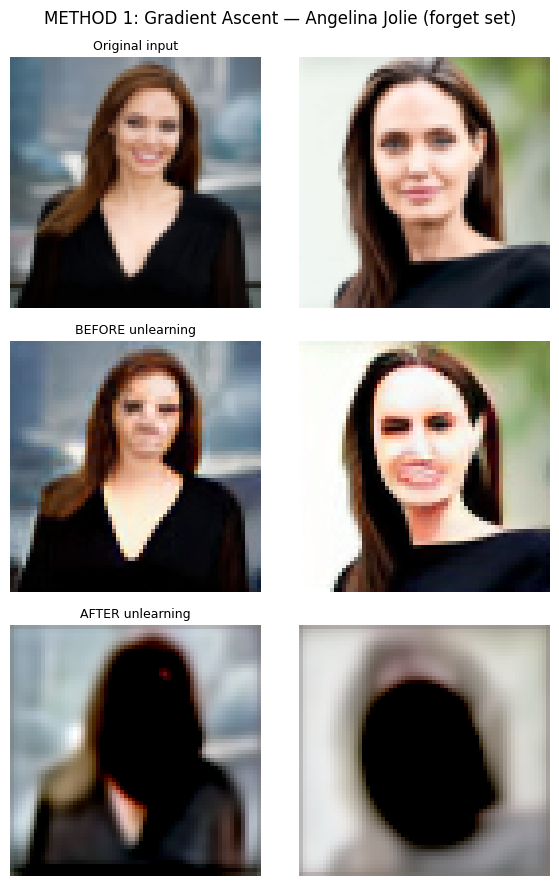

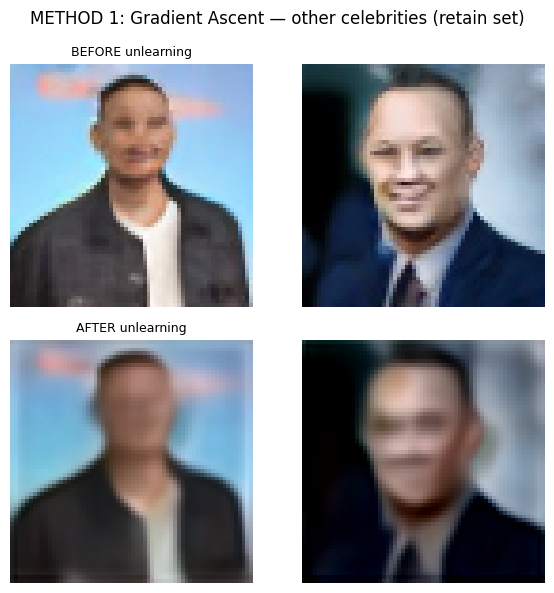


                              Before      After
Forget MSE                   0.00550    0.12584  (+2186.8%)
Retain MSE                   0.00346    0.02194  (+533.3%)


In [6]:
# METHOD 1 VISUALIZATION

ga_model = copy.deepcopy(sd_vae)
ga_model.load_state_dict(ga_state)
ga_model.eval()

with torch.no_grad():
    forget_after = ((ga_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1)
    retain_after  = ((ga_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1)

fig, axes = plt.subplots(3, N, figsize=(N*3, 9))
for i in range(N):
    axes[0,i].imshow(test_forget[i].cpu().permute(1,2,0).clamp(0,1))
    axes[0,i].axis('off')
    if i==0: axes[0,i].set_title('Original input', fontsize=9)
    axes[1,i].imshow(forget_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes[1,i].axis('off')
    if i==0: axes[1,i].set_title('BEFORE unlearning', fontsize=9)
    axes[2,i].imshow(forget_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes[2,i].axis('off')
    if i==0: axes[2,i].set_title('AFTER unlearning', fontsize=9)
plt.suptitle(f"METHOD 1: Gradient Ascent — {FORGET_CELEB} (forget set)", fontsize=12)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, N, figsize=(N*3, 6))
for i in range(N):
    axes2[0,i].imshow(retain_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[0,i].axis('off')
    if i==0: axes2[0,i].set_title('BEFORE unlearning', fontsize=9)
    axes2[1,i].imshow(retain_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[1,i].axis('off')
    if i==0: axes2[1,i].set_title('AFTER unlearning', fontsize=9)
plt.suptitle("METHOD 1: Gradient Ascent — other celebrities (retain set)", fontsize=12)
plt.tight_layout()
plt.show()

fm_b = F.mse_loss(forget_before, test_forget).item()
fm_a = F.mse_loss(forget_after,  test_forget).item()
rm_b = F.mse_loss(retain_before, test_retain).item()
rm_a = F.mse_loss(retain_after,  test_retain).item()

ga_results = {'f_before': fm_b, 'f_after': fm_a, 'r_before': rm_b, 'r_after': rm_a}

print(f"\n{'':25} {'Before':>10} {'After':>10}")
print(f"{'Forget MSE':25} {fm_b:>10.5f} {fm_a:>10.5f}  ({(fm_a/fm_b-1)*100:+.1f}%)")
print(f"{'Retain MSE':25} {rm_b:>10.5f} {rm_a:>10.5f}  ({(rm_a/rm_b-1)*100:+.1f}%)")

del ga_model
torch.cuda.empty_cache()

# Method 2: Random Noise Targeting

In [7]:
# METHOD 2: RANDOM NOISE TARGETING

import copy, gc
torch.cuda.empty_cache()
gc.collect()

# deepcopy — sd_vae never touched
noise_model = copy.deepcopy(sd_vae)
noise_model.load_state_dict({k: v.clone() for k, v in original_weights.items()})
for p in noise_model.decoder.parameters():
    p.requires_grad_(True)

# BEFORE — from clean sd_vae
forget_before = decode(encode(test_forget))
retain_before  = decode(encode(test_retain))

noise_optimizer = torch.optim.Adam(noise_model.decoder.parameters(), lr=1e-5)
forget_iter = iter(forget_loader_64)
retain_iter = iter(retain_loader_64)

STEPS = 300
print("=== METHOD 2: NOISE TARGETING ===")
for step in range(STEPS):
    noise_model.train()
    torch.cuda.empty_cache()

    (imgs, _), forget_iter = safe_next(forget_iter, forget_loader_64)
    imgs = imgs.to(device)
    with torch.no_grad():
        latents = encode(imgs)
    noise_target = torch.rand_like(imgs) * 2 - 1
    recon = noise_model.decode(latents).sample
    loss_forget = 2.0 * F.mse_loss(recon, noise_target)

    (r_imgs, _), retain_iter = safe_next(retain_iter, retain_loader_64)
    r_imgs = r_imgs.to(device)
    with torch.no_grad():
        r_latents = encode(r_imgs)
    r_recon = noise_model.decode(r_latents).sample
    loss_retain = F.mse_loss(r_recon, r_imgs * 2 - 1)

    loss = loss_forget + 3.0 * loss_retain
    noise_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(noise_model.decoder.parameters(), 1.0)
    noise_optimizer.step()

    if step % 50 == 0 or step == STEPS - 1:
        noise_model.eval()
        with torch.no_grad():
            f_mse = F.mse_loss(
                ((noise_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1),
                test_forget).item()
            r_mse = F.mse_loss(
                ((noise_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1),
                test_retain).item()
        print(f"Step {step:3d} | Forget MSE: {f_mse:.5f} | Retain MSE: {r_mse:.5f}")
        noise_model.train()

noise_state = {k: v.clone() for k, v in noise_model.state_dict().items()}
del noise_model
torch.cuda.empty_cache()
print("Done.")

=== METHOD 2: NOISE TARGETING ===
Step   0 | Forget MSE: 0.00510 | Retain MSE: 0.00342
Step  50 | Forget MSE: 0.02733 | Retain MSE: 0.02132
Step 100 | Forget MSE: 0.03042 | Retain MSE: 0.01244
Step 150 | Forget MSE: 0.04333 | Retain MSE: 0.00470
Step 200 | Forget MSE: 0.05610 | Retain MSE: 0.00349
Step 250 | Forget MSE: 0.06747 | Retain MSE: 0.00305
Step 299 | Forget MSE: 0.06847 | Retain MSE: 0.00325
Done.


# Method 2: Random Noise Targeting Visualization

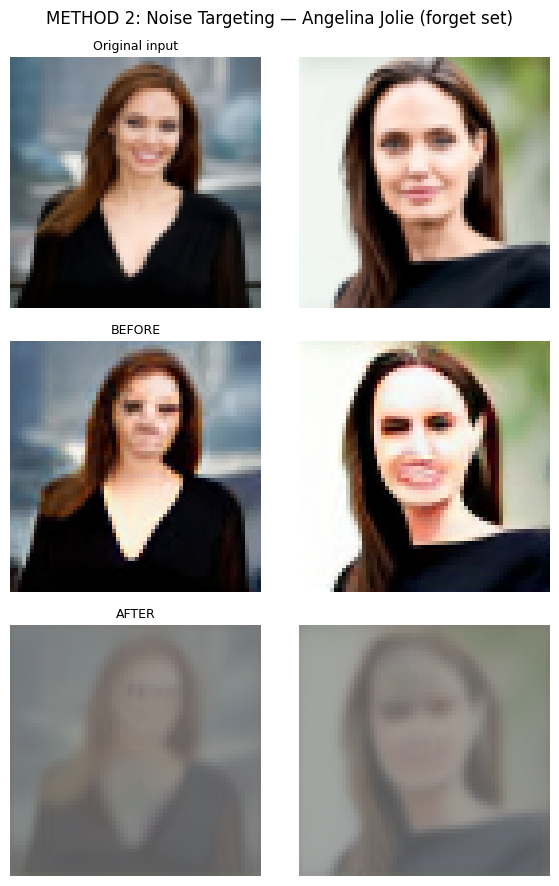

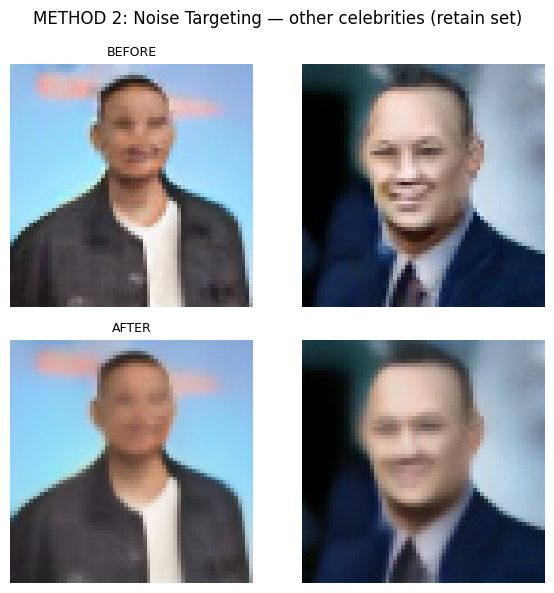


                              Before      After
Forget MSE                   0.00550    0.06847  (+1144.3%)
Retain MSE                   0.00346    0.00325  (-6.0%)


In [8]:
# METHOD 2 VISUALIZATION

import copy

noise_model = copy.deepcopy(sd_vae)
noise_model.load_state_dict(noise_state)
noise_model.eval()

# BEFORE — computed fresh from clean sd_vae right here
sd_vae.eval()
forget_before = decode(encode(test_forget))
retain_before  = decode(encode(test_retain))

# AFTER — from trained noise_model
with torch.no_grad():
    forget_after = ((noise_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1)
    retain_after  = ((noise_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1)


fig, axes = plt.subplots(3, N, figsize=(N*3, 9))
for i in range(N):
    axes[0,i].imshow(test_forget[i].cpu().permute(1,2,0).clamp(0,1))
    axes[0,i].axis('off')
    if i==0: axes[0,i].set_title('Original input', fontsize=9)
    axes[1,i].imshow(forget_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes[1,i].axis('off')
    if i==0: axes[1,i].set_title('BEFORE', fontsize=9)
    axes[2,i].imshow(forget_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes[2,i].axis('off')
    if i==0: axes[2,i].set_title('AFTER', fontsize=9)
plt.suptitle(f"METHOD 2: Noise Targeting — {FORGET_CELEB} (forget set)", fontsize=12)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, N, figsize=(N*3, 6))
for i in range(N):
    axes2[0,i].imshow(retain_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[0,i].axis('off')
    if i==0: axes2[0,i].set_title('BEFORE', fontsize=9)
    axes2[1,i].imshow(retain_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[1,i].axis('off')
    if i==0: axes2[1,i].set_title('AFTER', fontsize=9)
plt.suptitle("METHOD 2: Noise Targeting — other celebrities (retain set)", fontsize=12)
plt.tight_layout()
plt.show()

nm_f_b = F.mse_loss(forget_before, test_forget).item()
nm_f_a = F.mse_loss(forget_after,  test_forget).item()
nm_r_b = F.mse_loss(retain_before, test_retain).item()
nm_r_a = F.mse_loss(retain_after,  test_retain).item()
noise_results = {'f_before': nm_f_b, 'f_after': nm_f_a, 'r_before': nm_r_b, 'r_after': nm_r_a}

print(f"\n{'':25} {'Before':>10} {'After':>10}")
print(f"{'Forget MSE':25} {nm_f_b:>10.5f} {nm_f_a:>10.5f}  ({(nm_f_a/nm_f_b-1)*100:+.1f}%)")
print(f"{'Retain MSE':25} {nm_r_b:>10.5f} {nm_r_a:>10.5f}  ({(nm_r_a/nm_r_b-1)*100:+.1f}%)")

del noise_model
torch.cuda.empty_cache()

# Method 3: Bad Teacher

In [9]:
# METHOD 3: BAD TEACHER
import copy, gc
torch.cuda.empty_cache()
gc.collect()

# Fresh model from file — sd_vae never touched
bt_model = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
bt_model.load_state_dict(torch.load('sd_vae_orig.pt'))
bt_model.eval()

# Bad teacher — random weights, frozen
bad_teacher_decoder = copy.deepcopy(bt_model.decoder)
for p in bad_teacher_decoder.parameters():
    torch.nn.init.normal_(p, mean=0.0, std=0.02)
for p in bad_teacher_decoder.parameters():
    p.requires_grad = False
bad_teacher_decoder.eval()

unlearn_optimizer = torch.optim.Adam(bt_model.decoder.parameters(), lr=1e-4)
forget_iter = iter(forget_loader_64)
retain_iter = iter(retain_loader_64)

STEPS = 300
print("=== METHOD 3: BAD TEACHER ===")
for step in range(STEPS):
    bt_model.train()
    torch.cuda.empty_cache()

    (imgs, _), forget_iter = safe_next(forget_iter, forget_loader_64)
    imgs = imgs.to(device)
    with torch.no_grad():
        latents = encode(imgs)
        bad_output = bad_teacher_decoder(latents)
    recon = bt_model.decode(latents).sample
    loss_forget = F.mse_loss(recon, bad_output.detach())

    (r_imgs, _), retain_iter = safe_next(retain_iter, retain_loader_64)
    r_imgs = r_imgs.to(device)
    with torch.no_grad():
        r_latents = encode(r_imgs)
    r_recon = bt_model.decode(r_latents).sample
    loss_retain = F.mse_loss(r_recon, r_imgs * 2 - 1)

    loss = loss_forget + 2.0 * loss_retain
    unlearn_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(bt_model.decoder.parameters(), 1.0)
    unlearn_optimizer.step()

    if step % 50 == 0 or step == STEPS - 1:
        bt_model.eval()
        with torch.no_grad():
            f_mse = F.mse_loss(
                ((bt_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1),
                test_forget).item()
            r_mse = F.mse_loss(
                ((bt_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1),
                test_retain).item()
        print(f"Step {step:3d} | Forget MSE: {f_mse:.5f} | Retain MSE: {r_mse:.5f}")
        bt_model.train()

bad_teacher_state = {k: v.clone() for k, v in bt_model.state_dict().items()}
del bt_model, bad_teacher_decoder
torch.cuda.empty_cache()
print("Bad teacher done.")

=== METHOD 3: BAD TEACHER ===
Step   0 | Forget MSE: 0.00380 | Retain MSE: 0.00370
Step  50 | Forget MSE: 0.04456 | Retain MSE: 0.00988
Step 100 | Forget MSE: 0.07576 | Retain MSE: 0.00648
Step 150 | Forget MSE: 0.06332 | Retain MSE: 0.00436
Step 200 | Forget MSE: 0.08736 | Retain MSE: 0.00412
Step 250 | Forget MSE: 0.09550 | Retain MSE: 0.00389
Step 299 | Forget MSE: 0.09608 | Retain MSE: 0.00567
Bad teacher done.


# Method 3: Bad Teacher Visualization

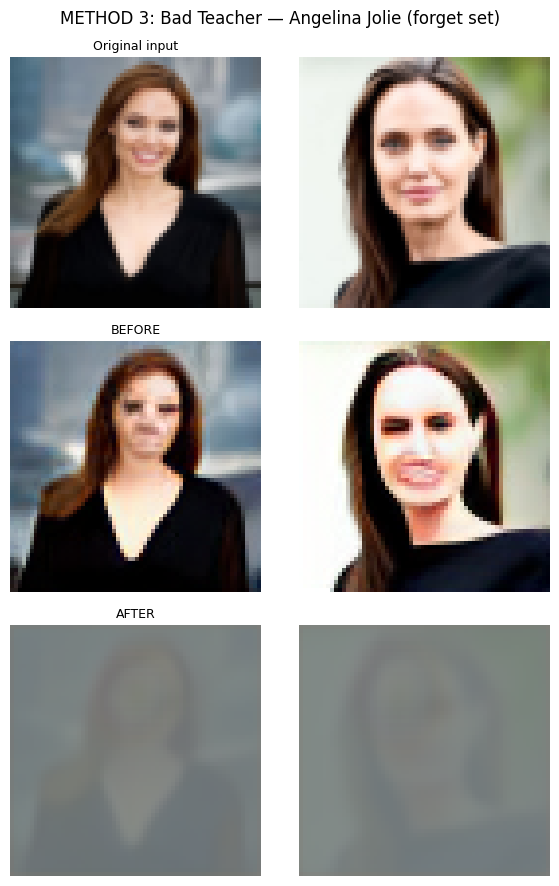

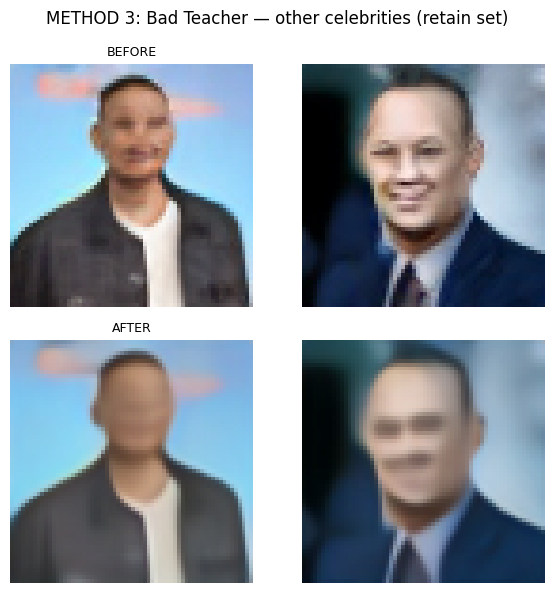


                              Before      After
Forget MSE                   0.00550    0.09608  (+1646.1%)
Retain MSE                   0.00346    0.00567  (+63.7%)


In [10]:
# METHOD 3 VISUALIZATION
import copy
bt_viz_model = copy.deepcopy(sd_vae)
bt_viz_model.load_state_dict(bad_teacher_state)
bt_viz_model.eval()

sd_vae.eval()
forget_before = decode(encode(test_forget))
retain_before  = decode(encode(test_retain))

with torch.no_grad():
    forget_after = ((bt_viz_model.decode(encode(test_forget)).sample+1)/2).clamp(0,1)
    retain_after  = ((bt_viz_model.decode(encode(test_retain)).sample+1)/2).clamp(0,1)

fig, axes = plt.subplots(3, N, figsize=(N*3, 9))
for i in range(N):
    axes[0,i].imshow(test_forget[i].cpu().permute(1,2,0).clamp(0,1))
    axes[0,i].axis('off')
    if i==0: axes[0,i].set_title('Original input', fontsize=9)
    axes[1,i].imshow(forget_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes[1,i].axis('off')
    if i==0: axes[1,i].set_title('BEFORE', fontsize=9)
    axes[2,i].imshow(forget_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes[2,i].axis('off')
    if i==0: axes[2,i].set_title('AFTER', fontsize=9)
plt.suptitle(f"METHOD 3: Bad Teacher — {FORGET_CELEB} (forget set)", fontsize=12)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(2, N, figsize=(N*3, 6))
for i in range(N):
    axes2[0,i].imshow(retain_before[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[0,i].axis('off')
    if i==0: axes2[0,i].set_title('BEFORE', fontsize=9)
    axes2[1,i].imshow(retain_after[i].cpu().permute(1,2,0).clamp(0,1))
    axes2[1,i].axis('off')
    if i==0: axes2[1,i].set_title('AFTER', fontsize=9)
plt.suptitle("METHOD 3: Bad Teacher — other celebrities (retain set)", fontsize=12)
plt.tight_layout()
plt.show()

bt_f_b = F.mse_loss(forget_before, test_forget).item()
bt_f_a = F.mse_loss(forget_after,  test_forget).item()
bt_r_b = F.mse_loss(retain_before, test_retain).item()
bt_r_a = F.mse_loss(retain_after,  test_retain).item()
bt_results = {'f_before': bt_f_b, 'f_after': bt_f_a, 'r_before': bt_r_b, 'r_after': bt_r_a}
print(f"\n{'':25} {'Before':>10} {'After':>10}")
print(f"{'Forget MSE':25} {bt_f_b:>10.5f} {bt_f_a:>10.5f}  ({(bt_f_a/bt_f_b-1)*100:+.1f}%)")
print(f"{'Retain MSE':25} {bt_r_b:>10.5f} {bt_r_a:>10.5f}  ({(bt_r_a/bt_r_b-1)*100:+.1f}%)")
del bt_viz_model
torch.cuda.empty_cache()

# **Latent Vector Injection**

Here we attempt to obtain the Angelina Jolie latent vector direction in the VAE's latent space, however the face shape and features are not retained.

In [11]:
import gc

# ── Hard clear any leftover models from previous methods ──────────────────────
for name in ['ga_model', 'noise_model', 'bt_model', 'bt_viz_model',
             'collapse_model', 'inject_model']:
    if name in dir():
        del globals()[name]
torch.cuda.empty_cache()
gc.collect()

# ── 1. Isolate Angelina's images ──────────────────────────────────────────────
transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

angelina_df = df[df["identity"] == "Angelina Jolie"].reset_index(drop=True)
print(f"Angelina images: {len(angelina_df)}")

angelina_loader = DataLoader(
    CelebDataset(angelina_df, transform_64),
    batch_size=4, shuffle=False
)

# ── 2. Extract direction directly from frozen sd_vae — no collapse model needed
sd_vae.eval()
all_latents = []
with torch.no_grad():
    for imgs, _ in angelina_loader:
        imgs = imgs.to(device)
        z = sd_vae.encode(imgs * 2 - 1).latent_dist.mean
        all_latents.append(z)

all_latents = torch.cat(all_latents, dim=0)
angelina_direction = all_latents.mean(dim=0, keepdim=True)

latent_std = all_latents.std(dim=0).mean().item()
print(f"Latent cluster std: {latent_std:.5f}")
print(f"Angelina direction norm: {angelina_direction.norm():.4f}")
print("Direction extracted.")

Angelina images: 100
Latent cluster std: 3.99769
Angelina direction norm: 25.4505
Direction extracted.


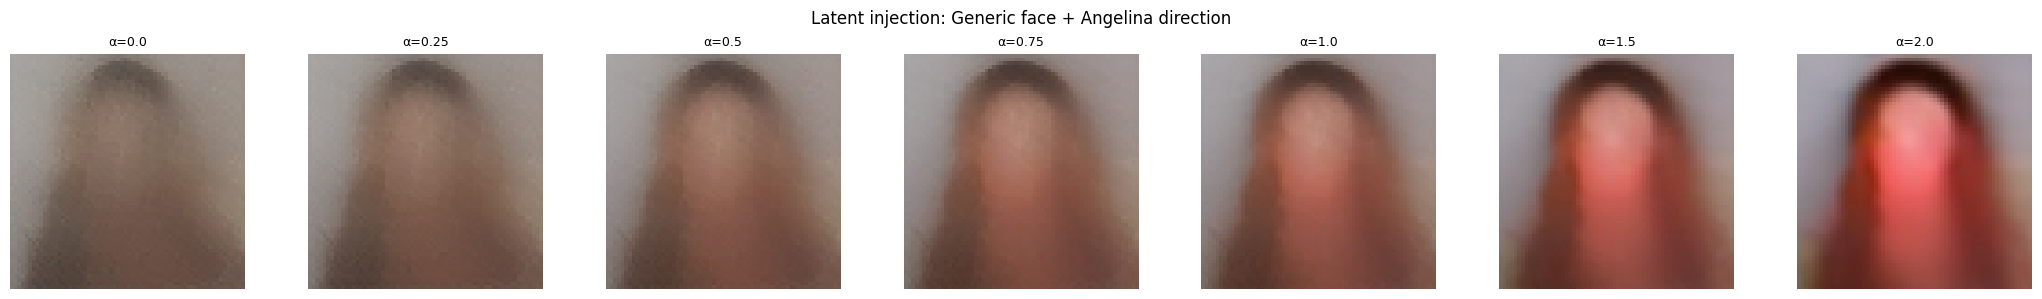

In [12]:
# ── VISUALIZATION: Latent vector injection ────────────────────────────────────

sd_vae.eval()

# Generic face = mean latent of a random retain batch
retain_loader_viz = DataLoader(
    CelebDataset(retain_df, transform_64),
    batch_size=16, shuffle=True
)
with torch.no_grad():
    generic_imgs, _ = next(iter(retain_loader_viz))
    generic_imgs = generic_imgs.to(device)
    generic_latent = sd_vae.encode(generic_imgs * 2 - 1).latent_dist.mean
    generic_direction = generic_latent.mean(dim=0, keepdim=True)

# Sweep: add increasing amounts of the Angelina direction to the generic latent
alphas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, len(alphas), figsize=(len(alphas) * 3, 3))
with torch.no_grad():
    for i, alpha in enumerate(alphas):
        blended = generic_direction + alpha * angelina_direction
        recon = sd_vae.decode(blended).sample
        recon_img = ((recon + 1) / 2).clamp(0, 1)
        axes[i].imshow(recon_img[0].cpu().permute(1, 2, 0))
        axes[i].axis("off")
        axes[i].set_title(f"α={alpha}", fontsize=9)

plt.suptitle("Latent injection: Generic face + Angelina direction", fontsize=12)
plt.tight_layout()
plt.show()

# **Comparison**

Here we compare the methods of Gradient Ascent, Random Noise Targeting, and Bad Teacher against each other. Gradient Ascent results in the most forget loss, however it also shows the most retain loss as well. Random Noise shows the least retain loss, yet the least forget loss as well. Bad Teacher exhibits the best mix of forget loss to retain loss, making it the most efficient method in this test.

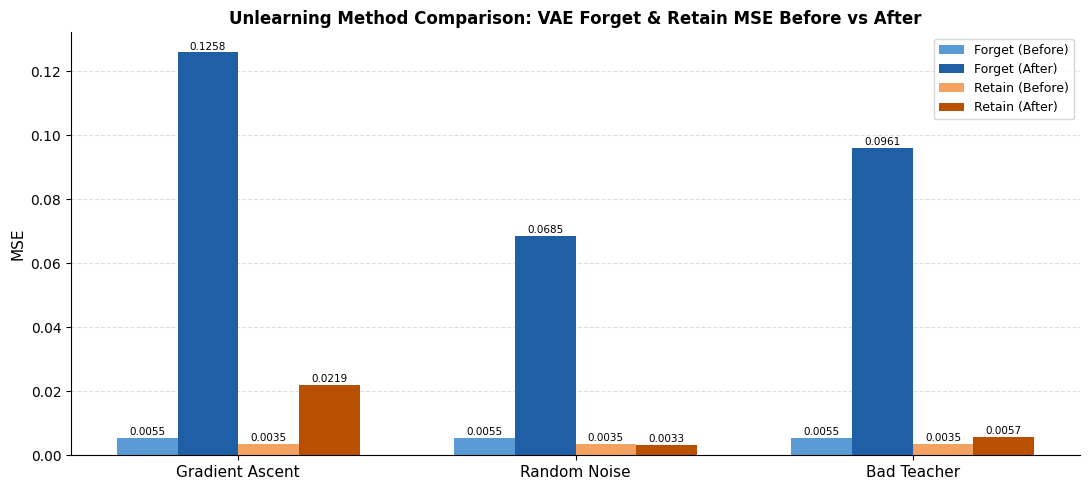

In [15]:
# COMPARISON GRAPH: All Methods — Forget & Retain MSE (Before & After)

import matplotlib.pyplot as plt
import numpy as np

methods = ['Gradient Ascent', 'Random Noise', 'Bad Teacher']
results = [ga_results, noise_results, bt_results]

forget_before = [r['f_before'] for r in results]
forget_after  = [r['f_after']  for r in results]
retain_before = [r['r_before'] for r in results]
retain_after  = [r['r_after']  for r in results]

x = np.arange(len(methods))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - 1.5*width, forget_before, width, label='Forget (Before)', color='#5b9bd5')
b2 = ax.bar(x - 0.5*width, forget_after,  width, label='Forget (After)',  color='#1f5fa6')
b3 = ax.bar(x + 0.5*width, retain_before, width, label='Retain (Before)', color='#f4a261')
b4 = ax.bar(x + 1.5*width, retain_after,  width, label='Retain (After)',  color='#b94f00')

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('MSE', fontsize=11)
ax.set_title('Unlearning Method Comparison: VAE Forget & Retain MSE Before vs After', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('unlearning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()